# 🎯 Estandarización de clase desde ZIP/RAR — Versión Fusión
**ExpoEscom — Clasificador Multietiqueta** · v4.2.0 (optimizado Colab Pro+ / A100)

**Fusiona lo mejor del notebook distribuido (Colab) y del script local,
y GARANTIZA exactamente MAX_IMAGENES en el dataset final:**

| Característica | Origen |
|---|---|
| Descarga desde carpeta compartida de Drive (PyDrive2) | notebook Colab |
| **Descarga paralela** (DOWNLOAD_WORKERS) con reintentos | v4.0 |
| Procesamiento **paralelo** por fuente (MAX_WORKERS) | notebook Colab |
| **Checkpoint** en Drive → resume automático tras reinicio | notebook Colab |
| **Filtro de duplicados exactos dHash** (umbral ≤ 2, solo idénticas/casi idénticas) | v4.1 |
| **GIF animado y MP4** → extrae un frame aleatorio y guarda como JPG | v4.2 |
| **Cuotas inteligentes**: fuentes chicas completas + redistribución de déficit | script local |
| **RARs anidados** dentro de ZIPs | script local |
| **Corte EXACTO** con contador global thread-safe (nunca de más) | v3.1 |
| **Augmentación de relleno PARALELA** como último recurso | v4.0 |
| **Guarda de espacio** en disco antes de descargar | v4.0 |

**Flujo de garantía de exactitud (FASE B):**
1. Pase normal. GIF → frame aleatorio (PIL seek). MP4 → frame del primer tercio (cv2).
2. Si faltan (fuentes agotadas): genera imágenes augmentadas en paralelo.

**Antes de correr, ajusta en CELDA 2:** `FOLDER_ID_POKEMON`, `CLASE`, `DATASET_DESTINO` y `MAX_IMAGENES`.

## CELDA 1 — Instalar dependencias y montar Drive

In [ ]:
# ============================================================
# Dependencias
# ============================================================
!apt-get install -y unrar > /dev/null 2>&1
!pip install PyDrive2 tqdm opencv-python-headless -q

import os, io, json, shutil, zipfile, subprocess, random, time, threading, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from PIL import Image
import cv2
from google.colab import drive, auth
from oauth2client.client import GoogleCredentials
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

# Silenciar el warning ruidoso de PIL (palette+transparency); convert('RGB') ya lo maneja
warnings.filterwarnings('ignore', category=UserWarning, module='PIL')

drive.mount('/content/drive', force_remount=False)
print('✅ unrar + PyDrive2 + OpenCV + Drive listos')

## CELDA 2 — Configuración (solo modifica aquí)

In [ ]:
# ════ CONFIGURACIÓN ═══════════════════════════════════════════

# ID de la carpeta compartida con los ZIP/RAR de origen (Compartidos conmigo)
FOLDER_ID_POKEMON = '1LP8h59yPavCtmFgUtXr9hrdmg5ltQlaL'  # ← pon aquí el ID de la carpeta de RUIDO

# Dataset destino en tu Drive
DATASET_DESTINO = '/content/drive/MyDrive/ExpoEscom/dataset/otra'

# Clase que estamos procesando
CLASE = 'noise'

# ── Meta total de imágenes ───────────────────────────────────
MAX_IMAGENES = 250_000   # ← 250k de ruido

# ── Paralelismo (Colab Pro+ / A100: ~12 vCPU, 83 GB RAM) ─────
MAX_WORKERS      = 12
DOWNLOAD_WORKERS = 4
LOTE_MULT        = 3
MAX_RONDAS       = 8

# ── Filtro de duplicados exactos (dHash) ─────────────────────
HASH_SIZE        = 8
UMBRAL_SIMILITUD = 2
INDEXAR_EXISTENTES = False  # no pre-carga las ya guardadas → solo deduplica lo nuevo entre sí

# ── Garantía de la meta EXACTA ───────────────────────────────
GARANTIZAR_EXACTO = True
PERMITIR_AUGMENT  = True

# ── Rutas ────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
SEED        = 42
TMP_DIR     = Path(f'/content/tmp_{CLASE}')
TMP_EXTRACT = TMP_DIR / 'extract'
DESTINO_CLASE   = Path(DATASET_DESTINO) / CLASE
CHECKPOINT_PATH = DESTINO_CLASE / '_checkpoint.json'

# MP4 y GIF animado: se extrae un frame aleatorio y se guarda como JPG
EXTENSIONES_IMAGEN = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.gif', '.mp4'}

for d in [TMP_DIR, TMP_EXTRACT, DESTINO_CLASE]:
    d.mkdir(parents=True, exist_ok=True)

random.seed(SEED)

print(f'Clase           : {CLASE}')
print(f'Meta imágenes   : {MAX_IMAGENES:,}')
print(f'Workers         : {MAX_WORKERS} extracción · {DOWNLOAD_WORKERS} descarga')
print(f'Filtro dHash    : umbral Hamming ≤ {UMBRAL_SIMILITUD} (solo duplicados exactos)')
print(f'Indexar existentes: {INDEXAR_EXISTENTES}')
print(f'Formatos        : imágenes estáticas + GIF (frame) + MP4 (frame)')
print(f'Destino         : {DESTINO_CLASE}')
print(f'Checkpoint      : {CHECKPOINT_PATH}')

## CELDA 3 — Autenticación y listado de archivos fuente

In [ ]:
# ── Autenticar con PyDrive2 ──────────────────────────────────
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive_api = GoogleDrive(gauth)

# ── Listar archivos en la carpeta compartida ─────────────────
query = f"'{FOLDER_ID_POKEMON}' in parents and trashed=false"
file_list = drive_api.ListFile({'q': query}).GetList()

EXT_SOPORTADAS = {'.zip', '.rar'}

archivos_drive = []
print(f"{'Archivo':<45} {'MB':>9}")
print('─' * 58)
for f in sorted(file_list, key=lambda x: x['title']):
    ext = Path(f['title']).suffix.lower()
    size_mb = int(f.get('fileSize', 0)) / (1024 * 1024) if f.get('fileSize') else 0
    print(f"{'📦' if ext in EXT_SOPORTADAS else '📁'} {f['title']:<43} {size_mb:>9.1f}")
    if ext in EXT_SOPORTADAS:
        archivos_drive.append({
            'id': f['id'], 'nombre': f['title'],
            'ext': ext, 'size_mb': size_mb,
        })

print(f"\nArchivos a procesar : {len(archivos_drive)}")
print(f"Tamaño total        : {sum(a['size_mb'] for a in archivos_drive)/1024:.2f} GB")

Archivo                                              MB
──────────────────────────────────────────────────────────
📦 cartas.rar                                    12312.4
📦 fanart.rar                                     2835.8
📦 official_art.rar                                290.9
📦 pokedex.rar                                     196.5
📦 pokemon_juego+.zip                             5522.2
📦 pokemon_primera_temporada.rar                  1258.8
📦 pokemon_segunda_temporada.rar                   589.3

Archivos a procesar : 7
Tamaño total        : 22.47 GB


## CELDA 4 — Filtro de variedad (dHash thread-safe)

In [ ]:
# ── dHash: hash perceptual de 64 bits ────────────────────────
def dhash(img: Image.Image) -> int:
    """Gradiente horizontal en rejilla 8x8 → 64 bits."""
    g = img.convert('L').resize((HASH_SIZE + 1, HASH_SIZE), Image.LANCZOS)
    px = list(g.getdata())
    h = 0
    for fila in range(HASH_SIZE):
        base = fila * (HASH_SIZE + 1)
        for col in range(HASH_SIZE):
            h = (h << 1) | int(px[base + col] > px[base + col + 1])
    return h


class IndiceSimilitud:
    """
    Índice de hashes perceptuales THREAD-SAFE para descartar imágenes
    muy parecidas, aun cuando varios hilos procesan fuentes en paralelo.

    Cada hash se indexa por sus 4 bloques de 16 bits: dos imágenes
    similares comparten casi siempre al menos un bloque exacto, así cada
    consulta compara contra un puñado de candidatos en vez de contra todo
    el dataset. Detección exacta hasta distancia 3, aproximada hasta el
    umbral — suficiente para variedad, no es dedup forense.
    """

    def __init__(self, umbral=UMBRAL_SIMILITUD):
        self.umbral   = umbral
        self._buckets = [{}, {}, {}, {}]
        self._lock    = threading.Lock()

    @staticmethod
    def _bloques(h):
        return ((h >> 48) & 0xFFFF, (h >> 32) & 0xFFFF,
                (h >> 16) & 0xFFFF, h & 0xFFFF)

    def _es_similar_unsafe(self, h):
        vistos = set()
        for i, b in enumerate(self._bloques(h)):
            for otro in self._buckets[i].get(b, ()):
                if otro in vistos:
                    continue
                vistos.add(otro)
                if bin(h ^ otro).count('1') <= self.umbral:
                    return True
        return False

    def _agregar_unsafe(self, h):
        for i, b in enumerate(self._bloques(h)):
            self._buckets[i].setdefault(b, []).append(h)

    def verificar_y_agregar(self, h) -> bool:
        """
        Operación ATÓMICA: si h no es similar a ninguno existente,
        lo agrega y retorna True (la imagen pasa). Si es similar,
        retorna False (descartar). El lock evita que dos hilos
        acepten simultáneamente dos imágenes casi idénticas.
        """
        with self._lock:
            if self._es_similar_unsafe(h):
                return False
            self._agregar_unsafe(h)
            return True

    def agregar(self, h):
        with self._lock:
            self._agregar_unsafe(h)

    def set_umbral(self, nuevo):
        """Relaja (o endurece) el umbral de similitud en caliente."""
        with self._lock:
            self.umbral = nuevo


def indexar_existentes(indice: IndiceSimilitud):
    """Hashea lo que ya está en destino para que las imágenes nuevas
    tampoco repitan lo ya guardado (resume coherente)."""
    rutas = list(DESTINO_CLASE.glob('*.jpg'))
    if not rutas:
        print('No hay imágenes previas que indexar.')
        return
    print(f'Indexando {len(rutas):,} imágenes existentes…')
    t0 = time.time()
    for i, ruta in enumerate(tqdm(rutas, unit='img'), 1):
        try:
            with Image.open(ruta) as img:
                indice.agregar(dhash(img))
        except Exception:
            continue
    print(f'Listo en {(time.time()-t0)/60:.1f} min')


print('✅ Filtro de variedad cargado')

✅ Filtro de variedad cargado


## CELDA 5 — Fuentes (ZIP, RAR y RARs anidados) + guardado thread-safe

In [ ]:
# ── Utilidades ───────────────────────────────────────────────
def es_imagen(nombre) -> bool:
    return Path(nombre).suffix.lower() in EXTENSIONES_IMAGEN


def _abrir_como_imagen(nombre, *, bytes_=None, ruta=None):
    """Abre cualquier formato soportado y devuelve PIL Image RGB.
    GIF animado → frame aleatorio.  MP4 → frame del primer tercio."""
    ext = Path(nombre).suffix.lower()

    if ext == '.mp4':
        # cv2 necesita ruta en disco; si viene de ZIP se escribe a /tmp
        if bytes_ is not None:
            tmp = Path(f'/tmp/_vid_{threading.get_ident()}.mp4')
            tmp.write_bytes(bytes_)
            path_mp4 = tmp
        else:
            path_mp4 = Path(ruta)
            tmp = None
        try:
            cap = cv2.VideoCapture(str(path_mp4))
            total = max(1, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
            cap.set(cv2.CAP_PROP_POS_FRAMES, random.randint(0, total // 3))
            ok, frame = cap.read()
            cap.release()
            if not ok:
                return None
            return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        except Exception:
            return None
        finally:
            if tmp is not None:
                tmp.unlink(missing_ok=True)

    # Imagen estática o GIF
    try:
        if bytes_ is not None:
            img = Image.open(io.BytesIO(bytes_))
        else:
            img = Image.open(ruta)
        if ext == '.gif':
            n = getattr(img, 'n_frames', 1)
            if n > 1:
                try:
                    img.seek(random.randint(0, n - 1))
                except EOFError:
                    img.seek(0)
        return img.convert('RGB')   # fuerza carga + normaliza modo
    except Exception:
        return None


# Índice global thread-safe para nombrar archivos sin colisiones
_lock_idx = threading.Lock()
_idx_global = [0]

def _siguiente_indice() -> int:
    with _lock_idx:
        i = _idx_global[0]
        _idx_global[0] += 1
    return i


# ── Contador global thread-safe (corte EXACTO en MAX_IMAGENES) ──
_lock_total = threading.Lock()
_total_guardadas = [0]

def _reservar_cupo() -> bool:
    with _lock_total:
        if _total_guardadas[0] >= MAX_IMAGENES:
            return False
        _total_guardadas[0] += 1
        return True

def _liberar_cupo():
    with _lock_total:
        _total_guardadas[0] -= 1

def _cupo_restante() -> int:
    with _lock_total:
        return max(0, MAX_IMAGENES - _total_guardadas[0])

def _inicializar_indice():
    maxidx = -1
    n_existentes = 0
    for f in DESTINO_CLASE.glob(f'{CLASE}_*.jpg'):
        n_existentes += 1
        try:
            n = int(f.stem[len(CLASE)+1:])
            maxidx = max(maxidx, n)
        except ValueError:
            pass
    _idx_global[0] = maxidx + 1
    _total_guardadas[0] = n_existentes

_inicializar_indice()


def procesar_imagen(img: Image.Image, indice: IndiceSimilitud, pbar) -> bool:
    h = dhash(img)
    if not indice.verificar_y_agregar(h):
        return False
    if not _reservar_cupo():
        return False
    try:
        idx  = _siguiente_indice()
        dest = DESTINO_CLASE / f'{CLASE}_{idx:06d}.jpg'
        img.convert('RGB').resize(IMG_SIZE, Image.LANCZOS).save(
            dest, 'JPEG', quality=90, optimize=True)
        pbar.update(1)
        return True
    except Exception:
        _liberar_cupo()
        return False


# ── Clases de fuente ─────────────────────────────────────────

class FuenteZip:
    def __init__(self, nombre, zip_path, nombres_dentro):
        self.nombre      = nombre
        self.zip_path    = Path(zip_path)
        self._nombres    = nombres_dentro
        self.disponibles = len(nombres_dentro)
        self.cuota       = 0
        self.guardadas   = 0
        self.agotada     = False

    def reabrir(self):
        self.agotada = False

    def extraer(self, indice, pbar) -> tuple:
        nombres = self._nombres[:]
        random.shuffle(nombres)
        nuevas = descartadas = 0
        try:
            with zipfile.ZipFile(self.zip_path) as zf:
                for nombre in nombres:
                    if self.guardadas >= self.cuota:
                        break
                    try:
                        with zf.open(nombre) as f:
                            data = f.read()
                        img = _abrir_como_imagen(nombre, bytes_=data)
                        if img is None:
                            continue
                        if procesar_imagen(img, indice, pbar):
                            nuevas += 1
                            self.guardadas += 1
                        else:
                            descartadas += 1
                    except Exception:
                        continue
                else:
                    self.agotada = True
        except Exception as e:
            print(f'  ⚠️ {self.nombre}: {e}', flush=True)
        return nuevas, descartadas


class FuenteRar:
    def __init__(self, nombre, rar_path=None, zip_origen=None, rar_interno=None):
        self.nombre      = nombre
        self.rar_path    = Path(rar_path) if rar_path else None
        self.zip_origen  = Path(zip_origen) if zip_origen else None
        self.rar_interno = rar_interno
        self.disponibles = -1
        self.cuota       = 0
        self.guardadas   = 0
        self.agotada     = False
        self._nombres    = None
        self._pendientes = None

    def reabrir(self):
        self.agotada = False
        self._pendientes = None

    def _asegurar_en_disco(self) -> bool:
        if self.rar_path and self.rar_path.exists():
            return True
        if not self.zip_origen:
            return False
        dest = TMP_EXTRACT / Path(self.rar_interno).name
        if not dest.exists():
            print(f'  → Extrayendo {dest.name} del ZIP…', flush=True)
            with zipfile.ZipFile(self.zip_origen) as zf:
                with zf.open(self.rar_interno) as src, open(dest, 'wb') as dst:
                    shutil.copyfileobj(src, dst)
        self.rar_path = dest
        return True

    def listar(self):
        if self._nombres is not None:
            return self._nombres
        if not self._asegurar_en_disco():
            return []
        r = subprocess.run(['unrar', 'lb', str(self.rar_path)],
                           capture_output=True, text=True, timeout=600)
        self._nombres = [l.strip() for l in r.stdout.splitlines()
                         if l.strip() and es_imagen(l.strip())]
        return self._nombres

    def contar(self) -> int:
        self.disponibles = len(self.listar())
        return self.disponibles

    def extraer(self, indice, pbar) -> tuple:
        if self._pendientes is None:
            self._pendientes = self.listar()[:]
            random.shuffle(self._pendientes)

        nuevas = descartadas = 0
        tmp = TMP_EXTRACT / f'batch_{self.nombre}_{threading.get_ident()}'

        while self.guardadas < self.cuota and self._pendientes:
            faltan = self.cuota - self.guardadas
            lote, self._pendientes = (self._pendientes[:faltan * LOTE_MULT],
                                      self._pendientes[faltan * LOTE_MULT:])
            tmp.mkdir(parents=True, exist_ok=True)
            listfile = TMP_EXTRACT / f'_list_{self.nombre}_{threading.get_ident()}.txt'
            listfile.write_text('\n'.join(lote))
            try:
                subprocess.run(
                    ['unrar', 'x', '-o+', str(self.rar_path),
                     f'@{listfile}', str(tmp) + '/'],
                    capture_output=True, timeout=14400)
            finally:
                listfile.unlink(missing_ok=True)

            rutas = [r for r in tmp.rglob('*') if r.is_file() and es_imagen(r.name)]
            random.shuffle(rutas)
            for ruta in rutas:
                if self.guardadas >= self.cuota:
                    break
                try:
                    img = _abrir_como_imagen(ruta.name, ruta=ruta)
                    if img is None:
                        continue
                    if procesar_imagen(img, indice, pbar):
                        nuevas += 1
                        self.guardadas += 1
                    else:
                        descartadas += 1
                except Exception:
                    continue
            shutil.rmtree(tmp, ignore_errors=True)

        if not self._pendientes:
            self.agotada = True
        return nuevas, descartadas


def descubrir_fuentes(ruta_local: Path):
    ext = ruta_local.suffix.lower()
    if ext == '.rar':
        return [FuenteRar(ruta_local.stem, rar_path=ruta_local)]

    fuentes = []
    with zipfile.ZipFile(ruta_local) as zf:
        entradas = [n for n in zf.namelist() if '__MACOSX' not in n]
    imgs = [n for n in entradas if es_imagen(n)]
    rars = [n for n in entradas if Path(n).suffix.lower() == '.rar']
    if imgs:
        fuentes.append(FuenteZip(ruta_local.stem, ruta_local, imgs))
    for rar in rars:
        fuentes.append(FuenteRar(Path(rar).stem,
                                 zip_origen=ruta_local, rar_interno=rar))
    return fuentes


print(f'✅ Fuentes cargadas  |  Próximo índice: {_idx_global[0]:,}')

## CELDA 6 — Checkpoint y cuotas inteligentes

In [ ]:
# ── Checkpoint (resume tras reinicio de Colab) ───────────────
def cargar_checkpoint() -> dict:
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH) as f:
            return json.load(f)
    return {}

def guardar_checkpoint(ckpt: dict):
    tmp = str(CHECKPOINT_PATH) + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(ckpt, f, indent=2)
    os.replace(tmp, str(CHECKPOINT_PATH))


# ── Cuotas inteligentes (estrategia del script local) ────────
def asignar_cuotas(fuentes, total):
    """
    De menor a mayor fuente: si una fuente cabe completa en su parte
    proporcional, se toma TODA (official_art, fanart… entran enteras)
    y su sobrante se reparte entre las fuentes más grandes. Las últimas
    (temporadas, juego) absorben el resto en partes iguales.
    Maximiza la variedad del dataset.
    """
    activas = sorted([f for f in fuentes if f.disponibles > 0 and not f.agotada],
                     key=lambda f: f.disponibles)
    restante = total
    for i, f in enumerate(activas):
        n_restantes = len(activas) - i
        cuota_ideal = -(-restante // n_restantes)   # ceil
        # cuota acumulada: lo ya guardado + lo nuevo de esta ronda
        f.cuota   = f.guardadas + min(cuota_ideal, f.disponibles - f.guardadas)
        restante -= (f.cuota - f.guardadas)


checkpoint = cargar_checkpoint()
ya_total   = sum(checkpoint.values())
print(f'Checkpoint: {ya_total:,} imágenes ya guardadas en ejecuciones previas')
print(f'Faltan    : {max(0, MAX_IMAGENES - ya_total):,}')

Checkpoint: 0 imágenes ya guardadas en ejecuciones previas
Faltan    : 100,000


## CELDA 7 — Pipeline distribuido con redistribución de déficit

In [ ]:
# ── Pipeline fusión ──────────────────────────────────────────
#
# FASE A (paralela): descargar archivos de Drive (DOWNLOAD_WORKERS a la vez,
#                    con reintentos) y descubrir fuentes (incl. RARs anidados)
# FASE B (paralela): rondas de extracción. En cada ronda:
#         1. asignar cuotas (chicas completas, déficit a las grandes)
#         2. ejecutar fuentes en paralelo con ThreadPoolExecutor (MAX_WORKERS)
#         3. si quedó déficit y aún hay fuentes con material → otra ronda
#         4. guardar checkpoint en Drive al final de cada ronda
#
# El filtro dHash (umbral 2) descarta solo duplicados exactos/casi exactos.
# No hay relajación progresiva del umbral — si las fuentes se agotan, se
# completa la meta con augmentación.

checkpoint = cargar_checkpoint()
# El conteo real en disco es la fuente de verdad para el resume
ya_en_disco = len(list(DESTINO_CLASE.glob(f'{CLASE}_*.jpg')))
ya_total = ya_en_disco

if ya_total >= MAX_IMAGENES:
    print(f'✅ Ya tenemos {ya_total:,} imágenes en disco. Nada que hacer.')
else:
    # ── Filtro de similitud ──────────────────────────────────
    indice = IndiceSimilitud(umbral=UMBRAL_SIMILITUD)
    if INDEXAR_EXISTENTES:
        indexar_existentes(indice)

    # ── FASE A: descargar y descubrir fuentes ────────────────
    print('\n' + '═' * 55)
    print('FASE A — DESCARGA Y DESCUBRIMIENTO DE FUENTES')
    print('═' * 55)

    # Guarda de espacio: todos los archivos viven en disco a la vez
    total_gb = sum(a['size_mb'] for a in archivos_drive) / 1024
    libre_gb = shutil.disk_usage('/content').free / (1024 ** 3)
    print(f'Descarga total : {total_gb:.1f} GB   |   Libre en /content: {libre_gb:.1f} GB')
    if total_gb > libre_gb * 0.9:
        print('⚠️  Podrían NO caber todos los archivos en disco a la vez.')
        print('    Si falla por espacio, procesa la carpeta en lotes (menos archivos por corrida).')

    # Descarga paralela y robusta — un GoogleDrive por hilo (httplib2 no es thread-safe)
    _dl_local = threading.local()
    def _drive_hilo():
        if not hasattr(_dl_local, 'd'):
            ga = GoogleAuth()
            ga.credentials = GoogleCredentials.get_application_default()
            _dl_local.d = GoogleDrive(ga)
        return _dl_local.d

    def _descargar(archivo):
        local = TMP_DIR / archivo['nombre']
        if local.exists():
            return archivo, local, 'caché'
        for intento in range(3):
            try:
                fd = _drive_hilo().CreateFile({'id': archivo['id']})
                fd.GetContentFile(str(local))
                return archivo, local, 'ok'
            except Exception as e:
                if local.exists():
                    local.unlink()      # limpia descarga parcial antes de reintentar
                if intento == 2:
                    return archivo, None, f'❌ {e}'
                time.sleep(5 * (intento + 1))
        return archivo, None, '❌ fallo'

    print(f'\n⬇️  Descargando {len(archivos_drive)} archivos '
          f'({DOWNLOAD_WORKERS} en paralelo, 3 reintentos)…')
    fuentes = []
    orden = sorted(archivos_drive, key=lambda a: a['size_mb'])
    with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as ex:
        for archivo, local, estado in tqdm(ex.map(_descargar, orden),
                                           total=len(orden), unit='archivo'):
            if local is None:
                print(f"   {estado} — {archivo['nombre']}", flush=True)
                continue
            try:
                fuentes.extend(descubrir_fuentes(local))
            except Exception as e:
                print(f"   ⚠️ No se pudo leer {archivo['nombre']}: {e}", flush=True)

    # Contar RARs (necesario para cuotas)
    print('\nContando imágenes por fuente…')
    for f in fuentes:
        if isinstance(f, FuenteRar):
            print(f'  {f.nombre}…', end='', flush=True)
            print(f' {f.contar():,}')
        else:
            print(f'  {f.nombre}: {f.disponibles:,}')

    # Restaurar progreso previo desde checkpoint
    for f in fuentes:
        f.guardadas = checkpoint.get(f.nombre, 0)

    fuentes.sort(key=lambda f: f.disponibles)
    print('\n' + '─' * 55)
    print('FUENTES (menor → mayor)')
    print('─' * 55)
    for f in fuentes:
        print(f'  {f.nombre:<40s} {f.disponibles:>9,} imgs  (ya: {f.guardadas:,})')

    # ── FASE B: rondas paralelas con garantía de exactitud ───
    print('\n' + '═' * 55)
    print('FASE B — EXTRACCIÓN PARALELA POR RONDAS')
    print('═' * 55)

    pbar = tqdm(total=MAX_IMAGENES, initial=ya_total,
                desc='Imágenes guardadas', unit='img', dynamic_ncols=True)

    estado_global = {'descartadas': 0}

    def correr_rondas():
        """Ejecuta hasta MAX_RONDAS rondas paralelas con el umbral actual.
        Para en cuanto se llena el cupo global o no quedan fuentes."""
        ronda = 0
        while ronda < MAX_RONDAS:
            ronda += 1
            if _cupo_restante() <= 0:
                break
            disponibles = [f for f in fuentes if not f.agotada
                           and f.guardadas < f.disponibles]
            if not disponibles:
                break

            asignar_cuotas(fuentes, MAX_IMAGENES)
            activas = [f for f in disponibles if f.cuota > f.guardadas]
            if not activas:
                break

            print(f'\n── RONDA {ronda} ──  faltan {_cupo_restante():,} imgs, '
                  f'{len(activas)} fuentes activas')

            with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
                futs = {ex.submit(f.extraer, indice, pbar): f for f in activas}
                for fut in as_completed(futs):
                    f = futs[fut]
                    try:
                        nuevas, desc = fut.result()
                        estado_global['descartadas'] += desc
                        checkpoint[f.nombre] = f.guardadas
                        guardar_checkpoint(checkpoint)
                        print(f'   ✅ {f.nombre}: +{nuevas:,} '
                              f'({desc:,} descartadas por similitud)', flush=True)
                    except Exception as e:
                        print(f'   ❌ {f.nombre}: {e}', flush=True)

    # ── PASO 1: pase normal ───────────────────────────────────
    correr_rondas()

    # ── PASO 2: augmentación PARALELA como último recurso ────
    n_augmentadas = 0
    if GARANTIZAR_EXACTO and PERMITIR_AUGMENT and _cupo_restante() > 0:
        from PIL import ImageEnhance

        objetivo_aug = _cupo_restante()
        print('\n' + '·' * 55)
        print(f'🎨 Las fuentes se agotaron — generando {objetivo_aug:,} '
              f'imágenes AUGMENTADAS ({MAX_WORKERS} hilos) para completar {MAX_IMAGENES:,}')
        print('·' * 55)

        base = sorted(DESTINO_CLASE.glob(f'{CLASE}_*.jpg'))

        def augmentar(img):
            """Aplica una transformación aleatoria que conserva la clase."""
            op = random.choice(['flip', 'rot', 'bright', 'contrast', 'zoom', 'combo'])
            if op in ('flip', 'combo'):
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            if op in ('rot', 'combo'):
                img = img.rotate(random.uniform(-18, 18),
                                 resample=Image.BILINEAR, expand=False)
            if op in ('bright', 'combo'):
                img = ImageEnhance.Brightness(img).enhance(random.uniform(0.75, 1.25))
            if op in ('contrast', 'combo'):
                img = ImageEnhance.Contrast(img).enhance(random.uniform(0.75, 1.25))
            if op in ('zoom', 'combo'):
                w, h = img.size
                fz = random.uniform(0.8, 0.95)
                cw, ch = int(w * fz), int(h * fz)
                x, y = random.randint(0, w - cw), random.randint(0, h - ch)
                img = img.crop((x, y, x + cw, y + ch)).resize((w, h), Image.LANCZOS)
            return img

        def _aug_one(_):
            if not _reservar_cupo():
                return False
            try:
                origen = random.choice(base)
                with Image.open(origen) as im:
                    aug = augmentar(im.convert('RGB'))
                idx  = _siguiente_indice()
                dest = DESTINO_CLASE / f'{CLASE}_{idx:06d}.jpg'
                aug.resize(IMG_SIZE, Image.LANCZOS).save(
                    dest, 'JPEG', quality=90, optimize=True)
                return True
            except Exception:
                _liberar_cupo()
                return False

        if not base:
            print('   ⚠️ No hay imágenes base para augmentar; meta no alcanzable.')
        else:
            with tqdm(total=objetivo_aug, desc='Augmentando', unit='img') as pbar_aug:
                while _cupo_restante() > 0:
                    antes = n_augmentadas
                    faltan_aug = _cupo_restante()
                    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
                        for ok in ex.map(_aug_one, range(faltan_aug)):
                            if ok:
                                n_augmentadas += 1
                                pbar.update(1)
                                pbar_aug.update(1)
                    if n_augmentadas == antes:
                        print('   ⚠️ No se pudo augmentar más (imágenes base con errores).')
                        break
            checkpoint['_augmentadas'] = checkpoint.get('_augmentadas', 0) + n_augmentadas
            guardar_checkpoint(checkpoint)

    pbar.close()

    # ── Limpieza de archivos descargados ─────────────────────
    for archivo in archivos_drive:
        local = TMP_DIR / archivo['nombre']
        if local.exists():
            local.unlink()
    print('\n🗑️  Archivos descargados eliminados de /content/')

    # Conteo real en disco (fuente de verdad)
    total_final = len(list(DESTINO_CLASE.glob(f'{CLASE}_*.jpg')))
    reales = total_final - n_augmentadas
    print('\n' + '═' * 55)
    print('RESUMEN FINAL')
    print('═' * 55)
    print(f'  Imágenes en disco       : {total_final:,}')
    print(f'    · reales (fuentes)    : {reales:,}')
    print(f'    · augmentadas         : {n_augmentadas:,}')
    print(f'  Descartadas (similitud) : {estado_global["descartadas"]:,}')
    print(f'  Meta                    : {MAX_IMAGENES:,}')
    if total_final == MAX_IMAGENES:
        estado = '✅ EXACTO — meta lograda'
    elif total_final > MAX_IMAGENES:
        estado = f'⚠️ {total_final - MAX_IMAGENES} de más (revisa cortes)'
    else:
        estado = '⚠️ INCOMPLETO — ni augmentación alcanzó (¿sin imágenes base?)'
    print(f'  Estado                  : {estado}')
    print(f'  Destino                 : {DESTINO_CLASE}')

## CELDA 8 — Verificación final

Total imágenes en dataset : 100,000
Verificación (100 muestras): 100/100 válidas
✅ Todas 224×224 RGB


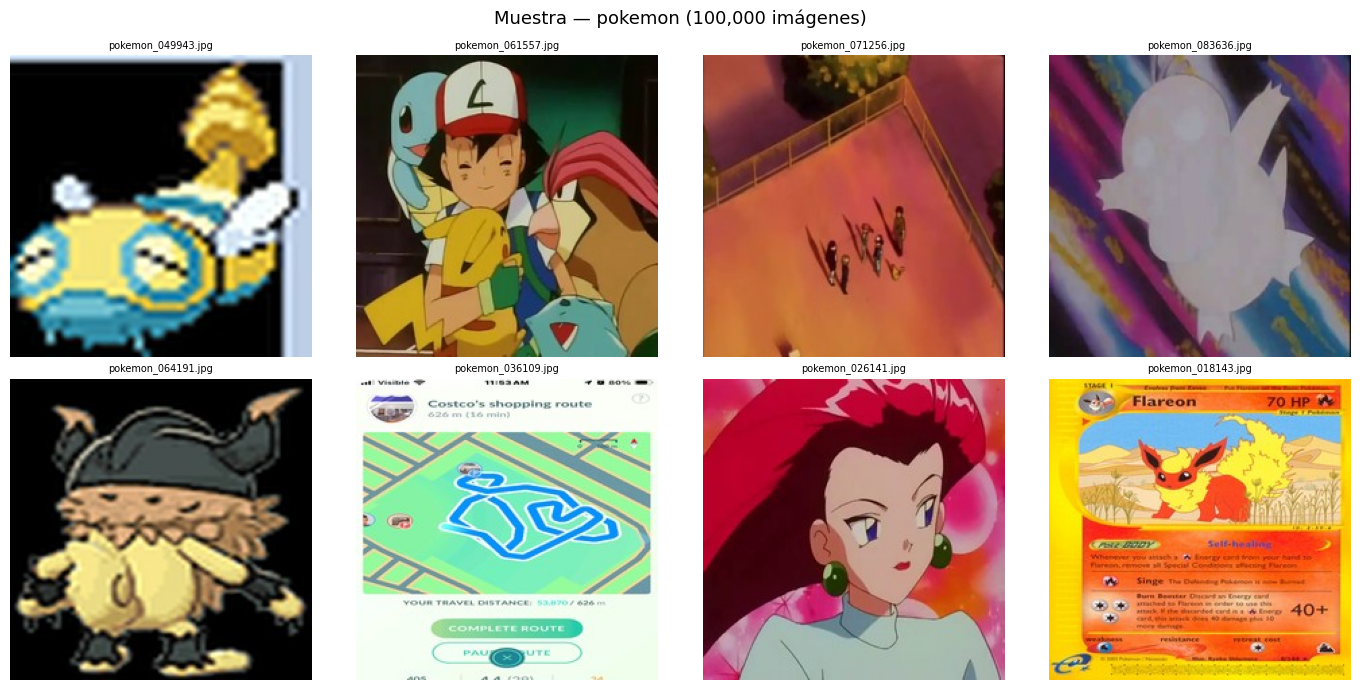


🎯 Dataset listo para entrenamiento.
   Ruta: /content/drive/MyDrive/ExpoEscom/dataset/pokemon


In [ ]:
# ── Verificar resultado ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

imagenes = sorted(DESTINO_CLASE.glob('*.jpg'))
print(f'Total imágenes en dataset : {len(imagenes):,}')

if imagenes:
    sample = random.sample(imagenes, min(100, len(imagenes)))
    corruptas = 0
    for ruta in sample:
        try:
            with Image.open(ruta) as img:
                assert img.size == IMG_SIZE, f'tamaño: {img.size}'
                assert img.mode == 'RGB',    f'modo: {img.mode}'
        except Exception:
            corruptas += 1

    print(f'Verificación ({len(sample)} muestras): '
          f'{len(sample)-corruptas}/{len(sample)} válidas')
    print('✅ Todas 224×224 RGB' if not corruptas
          else f'⚠️ {corruptas} con problemas')

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle(f'Muestra — {CLASE} ({len(imagenes):,} imágenes)', fontsize=13)
    for ax, ruta in zip(axes.flat,
                        random.sample(imagenes, min(8, len(imagenes)))):
        try:
            ax.imshow(mpimg.imread(ruta))
            ax.set_title(ruta.name[:18], fontsize=7)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print(f'\n🎯 Dataset listo para entrenamiento.')
print(f'   Ruta: {DESTINO_CLASE}')

In [ ]:
# ── Conteo rápido de imágenes en carpeta destino ─────────────
from pathlib import Path

_destino = Path(DATASET_DESTINO) / CLASE
_imagenes = list(_destino.glob('*.jpg'))

print(f'Carpeta : {_destino}')
print(f'Total   : {len(_imagenes):,} imágenes')
print(f'Meta    : {MAX_IMAGENES:,}')
print(f'Faltan  : {max(0, MAX_IMAGENES - len(_imagenes)):,}')


## CELDA 9 — Limpieza (corre al terminar)

In [ ]:
# ── Limpiar /content/ ────────────────────────────────────────
# El checkpoint en Drive se conserva por si necesitas re-ejecutar.

if TMP_DIR.exists():
    shutil.rmtree(TMP_DIR)
    print(f'✅ Limpiado: {TMP_DIR}')
else:
    print('ℹ️  No hay temporales que limpiar')

print('\n📊 Espacio en disco actual:')
!df -h /content | tail -1

✅ Limpiado: /content/tmp_pokemon

📊 Espacio en disco actual:
overlay         108G   24G   85G  22% /
